In [1]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles

<h4> Exercise1: 

<br>
    
a) Find the projections of the points $(3,2)$ and $(-2,0)$ onto the vector $v=[3,4]$
    
b) Find the projections of the points $(3,2,1)$ and $(-2,0,1)$ onto the vector $v=[3,4,-12]$

In [2]:
def projection(vec1, vec2):
    return np.dot(np.dot(vec1,vec2),vec2) / np.linalg.norm(vec2)**2

#a)

A = np.array([3,2])
B = np.array([-2,0])
v = np.array([3,4])

print(projection(A,v), projection(B,v))

#b)
A2 = np.array([3,2,1])
B2 = np.array([-2,0,1])
v2 = np.array([3,4,-12])

print(projection(A2, v2), projection(B2, v2))

[2.04 2.72] [-0.72 -0.96]
[ 0.0887574   0.1183432  -0.35502959] [-0.31952663 -0.4260355   1.27810651]


<h4> 
Question: Is it possible that the first two components explain 100% of the variance of the 5D data? If not - prove, if yes - give an example.

In [ ]:
#Yes:) - 3 features have no variance or are a a linear combination of remaining 2 features

<h4> Exercise2: Consider the iris dataset. Standardize it, and then apply the PCA algorithm.
How many components are sufficient to describe the data?
Which of the original features has the strongest impact on the first principal component?
Build an SVM classifier using both the original features and the reduced set of features (from PCA).
Comment on your results.

(150, 2)


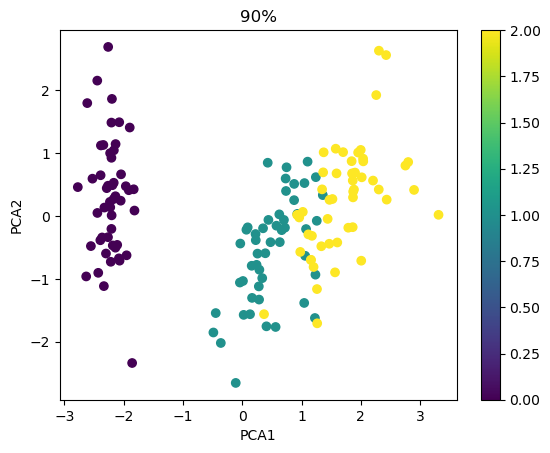

Accuracy on data: 0.88
Accuracy on PCA data: 0.88
[0.72962445 0.22850762]
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


In [3]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
iris = load_iris()

X, y = iris.data, iris.target

#standarise
stdsc = StandardScaler()
X = stdsc.fit_transform(X)

#reduce dims
pca = PCA(n_components=0.90) #4 components shoud be sufficient
iris90 = pca.fit_transform(X) #reduce features to 2 dims
print(iris90.shape)

plt.scatter(iris90[:,0], iris90[:,1],
            c = iris.target)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title('90%')
plt.colorbar()
plt.show()

#in 80% and 90% variance cases 2 dims are suffcient

#svm
svm = SVC(kernel = 'linear', C=0.01, random_state= 42)
svm.fit(X,y)
normal = svm.score(X,y)
svm.fit(iris90,y)
reduced = svm.score(iris90,y)
print(f'Accuracy on data: {normal}\nAccuracy on PCA data: {reduced}')
#usunięte cechy nie obnizyły dokładności

print(pca.explained_variance_ratio_)
print(pca.components_)

#pierwszy wektor ma wariancje 72% (jest dużo ważniejszy)
#patrząc na wagi cech w tym wektorze 2 jest najmniej ważna, a reszta porównywalna

<h4> Exercise3: Consider the codon log frequencies in selected plants, viruses, and bacteria. 
    
- Standardize the data. Then, perform PCA with 2 components. Visualize the reduced data, coloring the observations according to their kingdom. Next, apply LDA with 2 components and visualize the reduced data, again coloring observations by kingdom. Provide comments on the differences between the PCA and LDA visualizations.

- Finally, perform k-means clustering with 3 clusters on the LDA-reduced data. Evaluate how well the predicted clusters correspond to the actual organism categories (kingdoms).

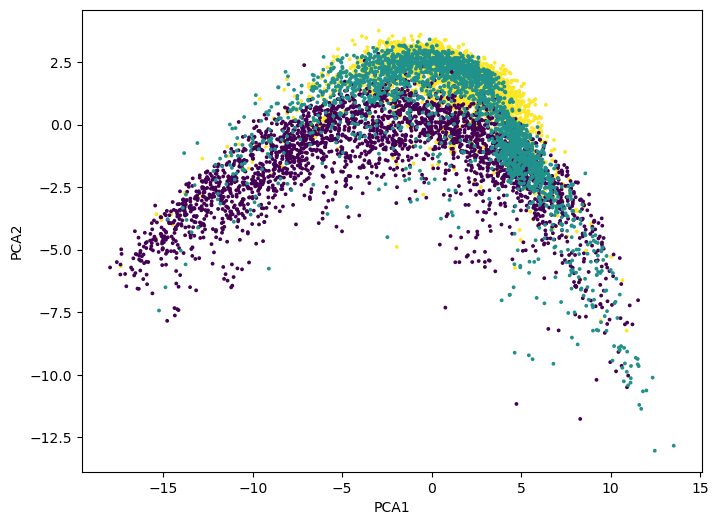

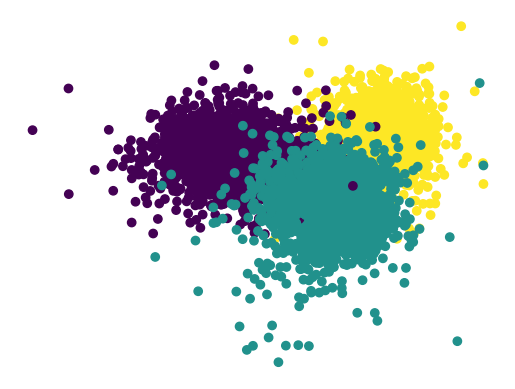

Accuracy: 0.925


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("codon_usage.csv")
df = df[df['Kingdom'].isin(['pln', 'vrl','bct'])]
# print(df.head())
# print(df.describe())
df['UGA;'] = df['UGA;'].str.replace(';', '')
y = df["Kingdom"]
X = df.drop(columns=["Kingdom","DNAtype", "SpeciesID", "Ncodons", "SpeciesName"]).apply(pd.to_numeric, errors='coerce').apply(lambda x: np.log(x + 0.001))

#standardise
stdsc = StandardScaler()
X = stdsc.fit_transform(X)

#reduce dims
pca =PCA(2)
reduced =pca.fit_transform(X)

#colors
lab_to_num = {
    'bct' : 0,
    'pln' : 1,
    'vrl' :2
}
labels = y.map(lab_to_num)

#plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:,0], reduced[:,1],
            c = labels,s=3)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

#lda
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

plt.scatter(X_lda[:, 0], X_lda[:, 1], c = labels)
plt.axis("off")
plt.show()

#accuracy
from sklearn.metrics import accuracy_score
lda.fit(X, y)
y_pred = lda.predict(X)
acc = accuracy_score(y, y_pred)
print(f'Accuracy: {acc:.3f}')


<h4>Exercise 4: Influenza Virus Sequence Analysis</h4>

- Open the file **"influenza viruses"** containing nucleotide sequences of various influenza virus types.

- Represent each sequence as a vector of 4-mer frequencies, resulting in a matrix **X**. What is the number of features?

- Standardize the data.

- Reduce the number of features while preserving 95% of the variance (PCA). How many features remain?

- Apply ICA with 4 components to the PCA-transformed data.

- Use the resulting features to perform hierarchical clustering, and try to group viruses of the same type together. Comment on the results.

(38, 256)
Number of PCA features: 20


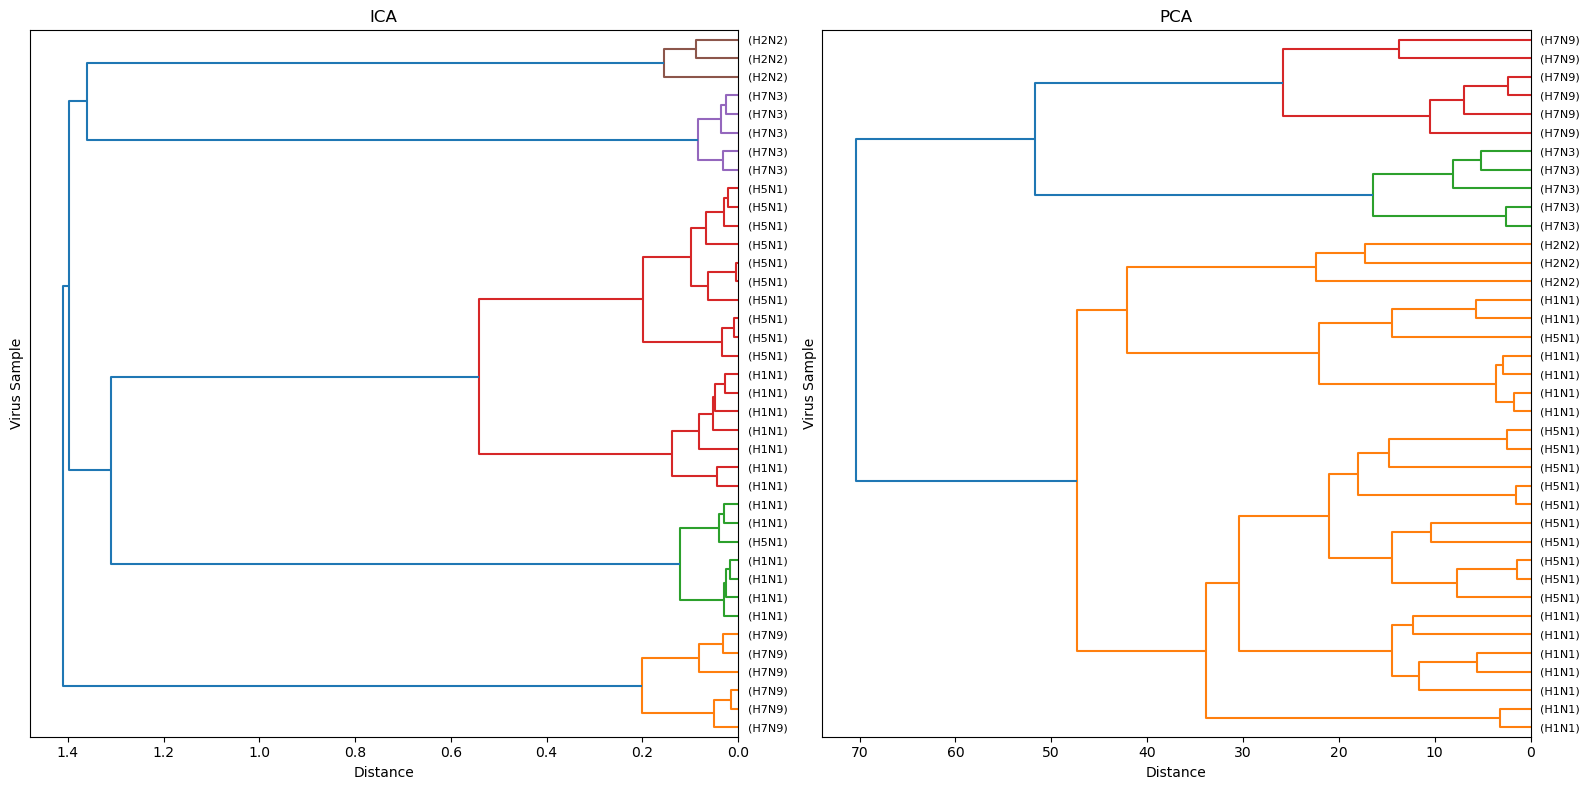

In [ ]:
with open('influenza_viruses', 'r') as file:
    virus = file.readlines()

lab = [virus[i].strip().replace('>', '') for i in range(0, len(virus), 2)]
virus_type = [i[-6:] for i in lab]
seq = [virus[i].strip() for i in range(1, len(virus), 2)]

def kmers(seq, k=4):
    d = {}
    N = len(seq)
    for i in range(N - k + 1):
        mer = seq[i:(i + k)]
        if mer not in d:
            d[mer] = 1
        else:
            d[mer] += 1
    return d

#df of kmer freq
kmer_freq = [kmers(s) for s in seq]
X = pd.DataFrame(kmer_freq).fillna(0) #change na to 0
print(X.shape) 

#stadarise
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

#pca
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  # Keep 95% of variance
X_pca = pca.fit_transform(X_std)

print(f"Number of PCA features: {X_pca.shape[1]}")


#ica - 4 components
from sklearn.decomposition import FastICA

ica = FastICA(n_components=4, whiten = "arbitrary-variance", random_state=42)
X_ica = ica.fit_transform(X_pca)

#hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage

#linkage matrix
link_pca = linkage(X_pca, method='ward', metric='euclidean')
link_ica = linkage(X_ica, method='ward', metric='euclidean')


from scipy.cluster.hierarchy import dendrogram

fig, axes = plt.subplots(1, 2, figsize=(16, 8))  #1 wiersz, 2 kolumny

#pca
dendrogram(link_pca, labels=virus_type, orientation='left', ax=axes[1])
axes[1].set_title("PCA")
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Virus Sample")

#ica
dendrogram(link_ica, labels=virus_type, orientation='left', ax=axes[0])
axes[0].set_title("ICA")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("Virus Sample")

plt.tight_layout()
plt.show()

#In ICA clustering was much better - it correctly identified the virus types, 
#PCA i clearly lacking - clustering different types together